# 01 — Índice de dependência assistencial por região de saúde

**Stories:** US-09 (definição, já entregue em `docs/definicao-indice-dependencia.md`) ·
US-10 (este notebook: cálculo, validação cruzada e ranking).
**Decisão de origem:** D-2 do gate do backlog — fórmula fechada, não reaberta aqui.

**O número.** O índice de dependência de uma região de saúde é a **porcentagem das
internações dos moradores daquela região que aconteceram fora dela**:

```
                internações de moradores de R realizadas FORA de R
índice(R) = 100 × ──────────────────────────────────────────────────
                    total de internações de moradores de R
```

Esse é o **diferencial do projeto**: não existe em nenhum painel público. A taxa de
evasão municipal (US-04/PA-1, 50,5%) já mostrada em outro notebook mistura "foi para a
cidade vizinha da mesma região" com "foi para outra região inteira" — e são situações
muito diferentes para quem pactua leitos entre regiões (PPI). O índice regional separa
essas duas coisas.

**Por que validar por três caminhos.** Este número vai para o painel Streamlit como *o*
indicador principal do projeto. Um erro de agregação aqui não é um detalhe — é o
produto. Por isso ele é calculado **três vezes, de fontes diferentes**, e as três contas
são comparadas com uma quarta: um CSV que já existia de uma etapa anterior
(`taxas_evasao_regional.csv`). Se não baterem, há um bug em algum lugar da
cadeia, e é preferível descobrir isso agora — em julho, no notebook — do que na
apresentação de 07/08/2026.

- **Caminho A** — parte da matriz origem→destino já agregada por **região**
  (`matriz_od_regional_mensal.csv`, US-06).
- **Caminho B** — parte da matriz origem→destino agregada por **município**
  (`matriz_od_municipal_mensal.parquet`, US-04) e faz a agregação para região
  **de novo, do zero**, mapeando cada código de município para sua região através de
  `regioes_saude_pb.csv` — sem reaproveitar as colunas `regiao_res`/`regiao_int` que já
  vêm prontas nesse arquivo. A ideia é não repetir o mesmo cálculo com uma cara
  diferente: se a US-04 tivesse um bug de mapeamento região↔município, reusar a coluna
  pronta esconderia o erro; refazendo o mapeamento eu mesmo, um bug ali apareceria como
  divergência entre A e B.
- **Caminho C** — parte da base **linha a linha**, uma AIH por vez
  (`sih_pb_2025_regioes.parquet`, 258.125 internações), sem nenhuma agregação
  intermediária. A e B partem de matrizes **já resumidas** por mês; se o passo que
  construiu essas matrizes tivesse um bug de agregação (uma dupla contagem, um mês
  perdido), ele passaria despercebido pelos Caminhos A e B igualmente. O Caminho C
  contorna esse risco contando cada internação individualmente. É o requisito explícito
  do critério de aceite AC1 da US-10: bater com "a base linha a linha".

**Saídas:** `data/processed/indice_dependencia_regional.csv` (tabela final, vai
alimentar o Streamlit), `outputs/figures/indice_ranking_dependencia.png` (gráfico) e o
veredito escrito no fim do notebook.

## 1. Carregando os dados

Cinco arquivos entram nesta conta:

- `regioes_saude_pb.csv` — o mapa oficial de qual município pertence a qual das 16
  regiões de saúde da PB (223 municípios).
- `matriz_od_regional_mensal.csv` — internações já agregadas por
  (região de residência → região de internação → mês). Fonte do **Caminho A**.
- `matriz_od_municipal_mensal.parquet` — internações agregadas por
  (município de residência → município de internação → mês). Fonte do **Caminho B**.
- `sih_pb_2025_regioes.parquet` — a base bruta do SIH, uma linha por AIH (internação),
  258.125 linhas, já com a região de residência e de internação de cada linha
  calculadas (etapa anterior do projeto). Fonte do **Caminho C**.
- `taxas_evasao_regional.csv` — um cálculo do índice já feito em etapa anterior do
  projeto. Entra só como **quarto ponto de comparação**, não como fonte de verdade.

**Nota técnica sobre acentuação.** Os nomes de região têm "ª" e "ã" (ex.: "3ª Região -
PB"). Esses arquivos estão gravados em UTF-8 — é a leitura padrão do `pandas.read_csv`,
sem precisar declarar `encoding`. (Se abrir esses CSVs num terminal Windows sem UTF-8, o
acento pode aparecer como um quadrado — é só a exibição do terminal, o dado está
correto; conferido byte a byte antes de escrever este notebook.)

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")


def br_milhar(valor):
    return f"{int(round(valor)):,}".replace(",", ".")


def br_pct(valor, casas=1):
    return f"{valor:.{casas}f}".replace(".", ",") + "%"


regioes = pd.read_csv("data/processed/regioes_saude_pb.csv")
matriz_regional = pd.read_csv("data/processed/matriz_od_regional_mensal.csv")
matriz_municipal = pd.read_parquet("data/processed/matriz_od_municipal_mensal.parquet")
sih_aih = pd.read_parquet(
    "data/processed/sih_pb_2025_regioes.parquet",
    columns=["regiao_res", "regiao_int"],
)
taxas_evasao_existente = pd.read_csv("data/processed/taxas_evasao_regional.csv")

print(f"regioes_saude_pb.csv: {len(regioes)} municípios, {regioes['codigo_regiao_saude'].nunique()} regiões")
print(f"matriz_od_regional_mensal.csv: {len(matriz_regional)} linhas, {int(matriz_regional['internacoes'].sum())} internações")
print(f"matriz_od_municipal_mensal.parquet: {len(matriz_municipal)} linhas, {int(matriz_municipal['internacoes'].sum())} internações")
print(f"sih_pb_2025_regioes.parquet: {len(sih_aih)} linhas (uma por AIH)")
print(f"taxas_evasao_regional.csv: {len(taxas_evasao_existente)} regiões")

assert regioes["codigo_regiao_saude"].nunique() == 16, "Esperava 16 regiões de saúde na PB"
assert (
    int(matriz_regional["internacoes"].sum())
    == int(matriz_municipal["internacoes"].sum())
    == len(sih_aih)
    == 258125
), "As três fontes deveriam representar a mesma base (258.125 internações de 2025)"
print("\nOK — as três fontes de entrada batem no total geral (258.125) antes de qualquer agregação.")

regioes_saude_pb.csv: 223 municípios, 16 regiões
matriz_od_regional_mensal.csv: 1677 linhas, 258125 internações
matriz_od_municipal_mensal.parquet: 15054 linhas, 258125 internações
sih_pb_2025_regioes.parquet: 258125 linhas (uma por AIH)
taxas_evasao_regional.csv: 16 regiões

OK — as três fontes de entrada batem no total geral (258.125) antes de qualquer agregação.


## 2. Caminho A — a partir da matriz regional

A `matriz_od_regional_mensal.csv` já vem com uma linha por
(`regiao_res`, `regiao_int`, `mes`). Para chegar no índice anual de cada região:

1. Somar todas as internações de moradores de cada região (os 12 meses juntos) → o
   **denominador**.
2. Dentro desse total, somar só as linhas em que `regiao_res == regiao_int` (internação
   dentro da própria região) → as que ficam "dentro".
3. "Fora" é o resto: denominador − dentro.
4. Índice = 100 × fora / denominador.

**Quem fica de fora da conta.** A matriz tem uma origem chamada `"Fora da PB"` — são
internações de gente que mora em outro estado e foi internada num hospital da Paraíba.
Como a US-09 define (seção 7 do documento de definição), o índice só existe para as 16
regiões da PB; "Fora da PB" não é uma região e não entra nem no numerador nem no
denominador de ninguém.

In [2]:
residentes_pb = matriz_regional[matriz_regional["regiao_res"] != "Fora da PB"].copy()

denominador_A = residentes_pb.groupby("regiao_res")["internacoes"].sum()
dentro_A = (
    residentes_pb[residentes_pb["regiao_res"] == residentes_pb["regiao_int"]]
    .groupby("regiao_res")["internacoes"]
    .sum()
)

caminho_A = pd.DataFrame({"internacoes_residentes": denominador_A}).join(
    dentro_A.rename("internacoes_dentro")
)
caminho_A["internacoes_dentro"] = caminho_A["internacoes_dentro"].fillna(0).astype(int)
caminho_A["internacoes_fora"] = caminho_A["internacoes_residentes"] - caminho_A["internacoes_dentro"]
caminho_A["indice_A"] = (100 * caminho_A["internacoes_fora"] / caminho_A["internacoes_residentes"]).round(1)

print(f"Regiões no Caminho A: {len(caminho_A)}")
print(f"Total de internações de residentes da PB somado: {br_milhar(caminho_A['internacoes_residentes'].sum())}")

assert len(caminho_A) == 16, "Caminho A deveria ter as 16 regiões"
assert int(caminho_A["internacoes_residentes"].sum()) == 256623, (
    "Total de residentes da PB divergiu do esperado (256.623, conforme docs/definicao-indice-dependencia.md)"
)
print("OK — total de residentes da PB confere com o documento de definição (256.623).")
caminho_A.sort_values("indice_A", ascending=False)

Regiões no Caminho A: 16
Total de internações de residentes da PB somado: 256.623
OK — total de residentes da PB confere com o documento de definição (256.623).


,internacoes_residentes,internacoes_dentro,internacoes_fora,indice_A
regiao_res,,,,
3ª Região - PB,10815,1672,9143,84.5
12ª Região - PB,10420,2941,7479,71.8
15ª Região - PB,9540,2714,6826,71.6
7ª Região - PB,8919,3890,5029,56.4
11ª Região - PB,4280,1951,2329,54.4
2ª Região - PB,16531,7545,8986,54.4
4ª Região - PB,7075,3238,3837,54.2
14ª Região - PB,10095,4846,5249,52.0
5ª Região - PB,8458,4866,3592,42.5


## 3. Caminho B — a partir da matriz municipal, remapeando região do zero

Aqui está o ponto central da validação cruzada. A `matriz_od_municipal_mensal.parquet`
**já tem** colunas `regiao_res` e `regiao_int` prontas (calculadas na US-04). Se eu
simplesmente as reusasse e agregasse, estaria repetindo o mesmo cálculo com um nome de
arquivo diferente — qualquer erro no mapeamento região↔município feito na US-04
apareceria idêntico nos dois caminhos, e a "validação" não validaria nada.

Por isso, o Caminho B ignora essas colunas prontas e refaz o mapeamento **por conta
própria**, usando só o código IBGE do município (`cod_mun_res`, `cod_mun_int`) e o
arquivo `regioes_saude_pb.csv` (que é o mapa oficial, também usado por outras stories,
mas numa junção nova, feita aqui).

**Municípios que não mapeiam.** `cod_mun_res` pode ser de fora da PB (paciente de outro
estado) — esses códigos não existem em `regioes_saude_pb.csv`, então o `map()` devolve
`NaN` e a linha é excluída, exatamente como o `"Fora da PB"` foi excluído no Caminho A.
`cod_mun_int`, por construção da base (é o SIH da Paraíba), só tem hospitais da própria
PB — não deveria sobrar `NaN` nesse lado; isso é conferido com um `assert` abaixo.

In [3]:
mapa_regiao = regioes.set_index("codigo_municipio")["nome_regiao_saude"]

municipal = matriz_municipal.copy()
municipal["cod_mun_res_num"] = pd.to_numeric(municipal["cod_mun_res"], errors="coerce")
municipal["cod_mun_int_num"] = pd.to_numeric(municipal["cod_mun_int"], errors="coerce")

municipal["regiao_res_B"] = municipal["cod_mun_res_num"].map(mapa_regiao)
municipal["regiao_int_B"] = municipal["cod_mun_int_num"].map(mapa_regiao)

sem_mapa_destino = municipal["regiao_int_B"].isna().sum()
assert sem_mapa_destino == 0, f"{sem_mapa_destino} linhas de destino não mapearam para nenhuma região — investigar!"

sem_mapa_origem = int(municipal.loc[municipal["regiao_res_B"].isna(), "internacoes"].sum())
print(f"Internações de residentes fora da PB (não mapeiam região, excluídas — igual ao 'Fora da PB' do Caminho A): {br_milhar(sem_mapa_origem)}")
assert sem_mapa_origem == 1502, "Volume de residentes fora da PB divergiu do esperado (1.502)"

residentes_pb_B = municipal.dropna(subset=["regiao_res_B"]).copy()

denominador_B = residentes_pb_B.groupby("regiao_res_B")["internacoes"].sum()
dentro_B = (
    residentes_pb_B[residentes_pb_B["regiao_res_B"] == residentes_pb_B["regiao_int_B"]]
    .groupby("regiao_res_B")["internacoes"]
    .sum()
)

caminho_B = pd.DataFrame({"internacoes_residentes": denominador_B}).join(
    dentro_B.rename("internacoes_dentro")
)
caminho_B["internacoes_dentro"] = caminho_B["internacoes_dentro"].fillna(0).astype(int)
caminho_B["internacoes_fora"] = caminho_B["internacoes_residentes"] - caminho_B["internacoes_dentro"]
caminho_B["indice_B"] = (100 * caminho_B["internacoes_fora"] / caminho_B["internacoes_residentes"]).round(1)
caminho_B.index.name = "regiao_res"

assert len(caminho_B) == 16, "Caminho B deveria ter as 16 regiões"
assert int(caminho_B["internacoes_residentes"].sum()) == 256623, "Total do Caminho B divergiu de 256.623"
print("OK — Caminho B também fecha em 256.623 internações de residentes da PB, remapeando do zero.")
caminho_B.sort_values("indice_B", ascending=False)

Internações de residentes fora da PB (não mapeiam região, excluídas — igual ao 'Fora da PB' do Caminho A): 1.502
OK — Caminho B também fecha em 256.623 internações de residentes da PB, remapeando do zero.


,internacoes_residentes,internacoes_dentro,internacoes_fora,indice_B
regiao_res,,,,
3ª Região - PB,10815,1672,9143,84.5
12ª Região - PB,10420,2941,7479,71.8
15ª Região - PB,9540,2714,6826,71.6
7ª Região - PB,8919,3890,5029,56.4
11ª Região - PB,4280,1951,2329,54.4
2ª Região - PB,16531,7545,8986,54.4
4ª Região - PB,7075,3238,3837,54.2
14ª Região - PB,10095,4846,5249,52.0
5ª Região - PB,8458,4866,3592,42.5


## 4. Caminho C — a partir da base AIH por AIH (sem nenhuma agregação intermediária)

Os Caminhos A e B partem de matrizes que **já foram somadas por mês** em etapas
anteriores do projeto (US-04 e US-06). Se aquele passo de agregação tivesse um erro —
por exemplo, um mês contado duas vezes, ou uma linha perdida na hora de somar —, o erro
estaria embutido nas duas matrizes e A e B continuariam batendo um com o outro sem que
isso significasse nada: os dois estariam errados **do mesmo jeito**.

O Caminho C fecha essa lacuna: parte de `sih_pb_2025_regioes.parquet`, que tem **uma
linha por AIH** (por internação), sem nenhuma soma prévia. Contar `regiao_res` aqui é
literalmente contar internação por internação — o critério de aceite AC1 da US-10 pede
exatamente isso: bater com "a base linha a linha".

In [4]:
sih_residentes_pb = sih_aih[sih_aih["regiao_res"] != "Fora da PB"].copy()

denominador_C = sih_residentes_pb.groupby("regiao_res").size()
dentro_C = sih_residentes_pb[
    sih_residentes_pb["regiao_res"] == sih_residentes_pb["regiao_int"]
].groupby("regiao_res").size()

caminho_C = pd.DataFrame({"internacoes_residentes": denominador_C}).join(
    dentro_C.rename("internacoes_dentro")
)
caminho_C["internacoes_dentro"] = caminho_C["internacoes_dentro"].fillna(0).astype(int)
caminho_C["internacoes_fora"] = caminho_C["internacoes_residentes"] - caminho_C["internacoes_dentro"]
caminho_C["indice_C"] = (100 * caminho_C["internacoes_fora"] / caminho_C["internacoes_residentes"]).round(1)

assert len(caminho_C) == 16, "Caminho C deveria ter as 16 regiões"
assert int(caminho_C["internacoes_residentes"].sum()) == 256623, "Total do Caminho C divergiu de 256.623"
print("OK — Caminho C também fecha em 256.623 internações de residentes da PB, contadas AIH por AIH.")
caminho_C.sort_values("indice_C", ascending=False)

OK — Caminho C também fecha em 256.623 internações de residentes da PB, contadas AIH por AIH.


,internacoes_residentes,internacoes_dentro,internacoes_fora,indice_C
regiao_res,,,,
3ª Região - PB,10815,1672,9143,84.5
12ª Região - PB,10420,2941,7479,71.8
15ª Região - PB,9540,2714,6826,71.6
7ª Região - PB,8919,3890,5029,56.4
11ª Região - PB,4280,1951,2329,54.4
2ª Região - PB,16531,7545,8986,54.4
4ª Região - PB,7075,3238,3837,54.2
14ª Região - PB,10095,4846,5249,52.0
5ª Região - PB,8458,4866,3592,42.5


## 5. Comparação: A × B × C × arquivo já existente

Agora a checagem que importa: colocar os três caminhos lado a lado com o
`taxas_evasao_regional.csv` que já existia (calculado numa etapa anterior do projeto,
antes deste notebook) e olhar a diferença região por região.

Critério: **delta zero** (ou, no máximo, arredondamento de casa decimal) entre os
quatro. Qualquer coisa maior que isso interrompe o notebook — não seguimos adiante
escolhendo o número "mais bonito".

In [5]:
existente = taxas_evasao_existente.set_index("regiao_res")["taxa_evasao_pct"].rename("indice_csv_existente")

comparacao = (
    caminho_A[["internacoes_residentes", "internacoes_dentro", "internacoes_fora", "indice_A"]]
    .join(caminho_B["indice_B"])
    .join(caminho_C["indice_C"])
    .join(existente)
)
comparacao["delta_A_B"] = (comparacao["indice_A"] - comparacao["indice_B"]).round(3)
comparacao["delta_A_C"] = (comparacao["indice_A"] - comparacao["indice_C"]).round(3)
comparacao["delta_A_csv"] = (comparacao["indice_A"] - comparacao["indice_csv_existente"]).round(3)
comparacao = comparacao.sort_values("indice_A", ascending=False)

print("Maior delta A vs B:  ", comparacao["delta_A_B"].abs().max())
print("Maior delta A vs C:  ", comparacao["delta_A_C"].abs().max())
print("Maior delta A vs CSV existente:", comparacao["delta_A_csv"].abs().max())

assert comparacao["delta_A_B"].abs().max() < 0.05, "Caminho A e Caminho B divergem além do arredondamento — INVESTIGAR"
assert comparacao["delta_A_C"].abs().max() < 0.05, "Caminho A e Caminho C divergem além do arredondamento — INVESTIGAR"
assert comparacao["delta_A_csv"].abs().max() < 0.05, "Caminho A e o CSV já existente divergem além do arredondamento — INVESTIGAR"

print("\nOK — os quatro números batem em todas as 16 regiões, sem exceção (delta < 0,05 ponto percentual em todos os casos).")
comparacao

Maior delta A vs B:   0.0
Maior delta A vs C:   0.0
Maior delta A vs CSV existente: 0.0

OK — os quatro números batem em todas as 16 regiões, sem exceção (delta < 0,05 ponto percentual em todos os casos).


,internacoes_residentes,internacoes_dentro,internacoes_fora,indice_A,indice_B,indice_C,indice_csv_existente,delta_A_B,delta_A_C,delta_A_csv
regiao_res,,,,,,,,,,
3ª Região - PB,10815,1672,9143,84.5,84.5,84.5,84.5,0.0,0.0,0.0
12ª Região - PB,10420,2941,7479,71.8,71.8,71.8,71.8,0.0,0.0,0.0
15ª Região - PB,9540,2714,6826,71.6,71.6,71.6,71.6,0.0,0.0,0.0
7ª Região - PB,8919,3890,5029,56.4,56.4,56.4,56.4,0.0,0.0,0.0
11ª Região - PB,4280,1951,2329,54.4,54.4,54.4,54.4,0.0,0.0,0.0
2ª Região - PB,16531,7545,8986,54.4,54.4,54.4,54.4,0.0,0.0,0.0
4ª Região - PB,7075,3238,3837,54.2,54.2,54.2,54.2,0.0,0.0,0.0
14ª Região - PB,10095,4846,5249,52.0,52.0,52.0,52.0,0.0,0.0,0.0
5ª Região - PB,8458,4866,3592,42.5,42.5,42.5,42.5,0.0,0.0,0.0


**Leitura do resultado da validação.** As quatro contas — três refeitas aqui de
fontes independentes (matriz regional, matriz municipal remapeada do zero e a base AIH
por AIH, sem agregação prévia) e uma que já existia de etapa anterior — batem
exatamente em todas as 16 regiões. Isso não era garantido: bastaria um erro de junção
(ex.: mapear um município para a região errada), de agregação (uma linha perdida ou
contada duas vezes na hora de montar a matriz mensal) ou de contagem para que A, B e C
divergissem entre si. Não divergiram — nem entre elas, nem contra o resultado
independente da base linha a linha. O índice está **validado por triangulação** antes de
ir para o painel.

## 6. Tabela final e ranking

A tabela final usa o Caminho A como fonte (A, B e C são idênticos após a validação
acima, então a escolha entre eles não muda nenhum número — fica o A por ser a matriz já
pensada em nível regional, mais direta). Colunas em português, prontas para o painel
Streamlit e para conferência manual em planilha.

In [6]:
indice_final = caminho_A.reset_index().rename(columns={
    "regiao_res": "regiao",
    "internacoes_residentes": "internacoes_residentes",
    "internacoes_dentro": "internacoes_realizadas_dentro",
    "internacoes_fora": "internacoes_realizadas_fora",
    "indice_A": "indice_dependencia_pct",
})
indice_final = indice_final.sort_values("indice_dependencia_pct", ascending=False).reset_index(drop=True)
indice_final.insert(0, "posicao", range(1, len(indice_final) + 1))

media_pb = 100 * indice_final["internacoes_realizadas_fora"].sum() / indice_final["internacoes_residentes"].sum()
print(f"Média estadual (mesmo cálculo, PB inteira como uma região só): {br_pct(media_pb)}")
assert abs(media_pb - 26.4) < 0.05, "Média estadual divergiu do valor documentado (26,4%)"
print("OK — média estadual confere com docs/definicao-indice-dependencia.md (26,4%).")

indice_final

Média estadual (mesmo cálculo, PB inteira como uma região só): 26,4%
OK — média estadual confere com docs/definicao-indice-dependencia.md (26,4%).


,posicao,regiao,internacoes_residentes,internacoes_realizadas_dentro,internacoes_realizadas_fora,indice_dependencia_pct
0,1,3ª Região - PB,10815,1672,9143,84.5
1,2,12ª Região - PB,10420,2941,7479,71.8
2,3,15ª Região - PB,9540,2714,6826,71.6
3,4,7ª Região - PB,8919,3890,5029,56.4
4,5,11ª Região - PB,4280,1951,2329,54.4
5,6,2ª Região - PB,16531,7545,8986,54.4
6,7,4ª Região - PB,7075,3238,3837,54.2
7,8,14ª Região - PB,10095,4846,5249,52.0
8,9,5ª Região - PB,8458,4866,3592,42.5
9,10,13ª Região - PB,4277,2802,1475,34.5


## 7. Os extremos: quem mais depende e quem menos depende

Usando os cortes já fechados na US-09 (< 26,4% baixa · 26,4–50% média · > 50% alta):

In [7]:
def faixa(indice):
    if indice < 26.4:
        return "baixa"
    if indice <= 50:
        return "média"
    return "alta"


indice_final["faixa_dependencia"] = indice_final["indice_dependencia_pct"].apply(faixa)

print("--- As 3 regiões mais dependentes ---")
for _, linha in indice_final.head(3).iterrows():
    print(f"  {linha['regiao']:<32} {br_pct(linha['indice_dependencia_pct'])}  "
          f"({br_milhar(linha['internacoes_residentes'])} internações de residentes)")

print("\n--- As 3 regiões menos dependentes (mais autossuficientes) ---")
for _, linha in indice_final.tail(3).iloc[::-1].iterrows():
    print(f"  {linha['regiao']:<32} {br_pct(linha['indice_dependencia_pct'])}  "
          f"({br_milhar(linha['internacoes_residentes'])} internações de residentes)")

print("\n--- Contagem por faixa ---")
print(indice_final["faixa_dependencia"].value_counts())

--- As 3 regiões mais dependentes ---
  3ª Região - PB                   84,5%  (10.815 internações de residentes)
  12ª Região - PB                  71,8%  (10.420 internações de residentes)
  15ª Região - PB                  71,6%  (9.540 internações de residentes)

--- As 3 regiões menos dependentes (mais autossuficientes) ---
  1ª Região Mata Atlântica - PB    1,8%  (81.574 internações de residentes)
  16ª Região - PB                  4,1%  (42.305 internações de residentes)
  9ª Região - PB                   21,6%  (13.385 internações de residentes)

--- Contagem por faixa ---
faixa_dependencia
alta     8
baixa    5
média    3
Name: count, dtype: int64


**Leitura leiga dos extremos.**

- **Mais dependente: 3ª Região (84,5%)** — de cada 100 internações de gente que mora
  nessa região (brejo/agreste: Esperança, Lagoa Seca, Alagoa Grande, Alagoa Nova, Areia,
  Remígio...), 85 acontecem fora dela, principalmente em Campina Grande, que fica ao
  lado. Na prática, essa região funciona como bairro de Campina Grande no que diz
  respeito a internação — não tem estrutura própria que segure a própria população.
- **Menos dependentes: 1ª Região Mata Atlântica (1,8%) e 16ª Região (4,1%)** — são,
  respectivamente, a região de João Pessoa e a de Campina Grande, os dois polos
  hospitalares do estado (o mesmo achado da análise de concentração de destinos, agora
  visto pelo lado de quem *recebe* em vez de quem *envia*). Praticamente todo mundo que
  mora nessas duas regiões se interna dentro delas — o que é esperado, já que são elas
  que recebem o excedente de quase todo o resto do estado.

Ou seja: os dois extremos contam a mesma história por ângulos opostos. A rede da PB tem
dois polos que resolvem quase tudo sozinhos e uma maioria de regiões — sobretudo as
vizinhas dos polos — que exportam a maior parte da própria demanda.

## 8. Veredito da hipótese PA-2

A pergunta analítica PA-2 do projeto (definida antes de olhar os resultados — ver
`docs/definicao-indice-dependencia.md`, seção 5) é: **pelo menos 1/3 das 16 regiões tem
dependência alta (índice > 50%)?** O teste é calculado, não estimado a olho.

In [8]:
n_alta = int((indice_final["faixa_dependencia"] == "alta").sum())
n_total = len(indice_final)
proporcao_alta = n_alta / n_total
limiar_pa2 = 1 / 3

print(f"Regiões em dependência alta (índice > 50%): {n_alta} de {n_total}")
print(f"Proporção observada: {n_alta}/{n_total} = {br_pct(100 * proporcao_alta)}")
print(f"Limiar da hipótese PA-2: 1/3 = {br_pct(100 * limiar_pa2)}")

pa2_confirmada = proporcao_alta >= limiar_pa2
print(f"\n{proporcao_alta:.3f} >= {limiar_pa2:.3f} -> hipótese PA-2 {'CONFIRMADA' if pa2_confirmada else 'REJEITADA'}")

assert n_alta == 8, f"Esperava 8 regiões em dependência alta, contei {n_alta} — investigar antes de seguir"
assert pa2_confirmada, "Hipótese PA-2 não se sustentou nos dados — revisar veredito"
print("\nOK — 8 de 16 regiões (50%) estão em dependência alta, folga de 16,7 pontos percentuais acima do limiar de 1/3 (33,3%).")

Regiões em dependência alta (índice > 50%): 8 de 16
Proporção observada: 8/16 = 50,0%
Limiar da hipótese PA-2: 1/3 = 33,3%

0.500 >= 0.333 -> hipótese PA-2 CONFIRMADA

OK — 8 de 16 regiões (50%) estão em dependência alta, folga de 16,7 pontos percentuais acima do limiar de 1/3 (33,3%).


**Hipótese PA-2: CONFIRMADA.** 8 de 16 regiões (50%) estão na faixa de dependência
alta — bem acima do limiar de 1/3 (33,3%) definido antes de olhar os resultados. Metade
das regiões de saúde da Paraíba, não um caso isolado, depende de outra região para a
maioria das internações da própria população.

## 9. Salvando a tabela final

Vai para `data/processed/`, no mesmo padrão dos outros arquivos processados do projeto
(é dali que o Streamlit vai ler).

In [9]:
Path("data/processed").mkdir(parents=True, exist_ok=True)
saida_csv = Path("data/processed/indice_dependencia_regional.csv")
indice_final.to_csv(saida_csv, index=False, encoding="utf-8")
print(f"Salvo: {saida_csv} ({saida_csv.stat().st_size / 1024:.1f} KB, {len(indice_final)} linhas)")

relido = pd.read_csv(saida_csv)
assert len(relido) == 16
assert int(relido["internacoes_residentes"].sum()) == 256623
print("Conferência pós-gravação: CSV relido tem 16 regiões e soma 256.623 internações de residentes — OK.")

Salvo: data\processed\indice_dependencia_regional.csv (0.9 KB, 16 linhas)
Conferência pós-gravação: CSV relido tem 16 regiões e soma 256.623 internações de residentes — OK.


## 10. Gráfico: o ranking das 16 regiões

Barras horizontais, ordenadas do maior índice para o menor, com a linha da média
estadual (26,4%) marcada, para dar a régua de comparação usada na interpretação. Título
em formato "afirmação" (RNF-04 do projeto): o gráfico já entrega a leitura, não só o
dado bruto.

Salvo: outputs\figures\indice_ranking_dependencia.png (198 KB, 200 dpi)


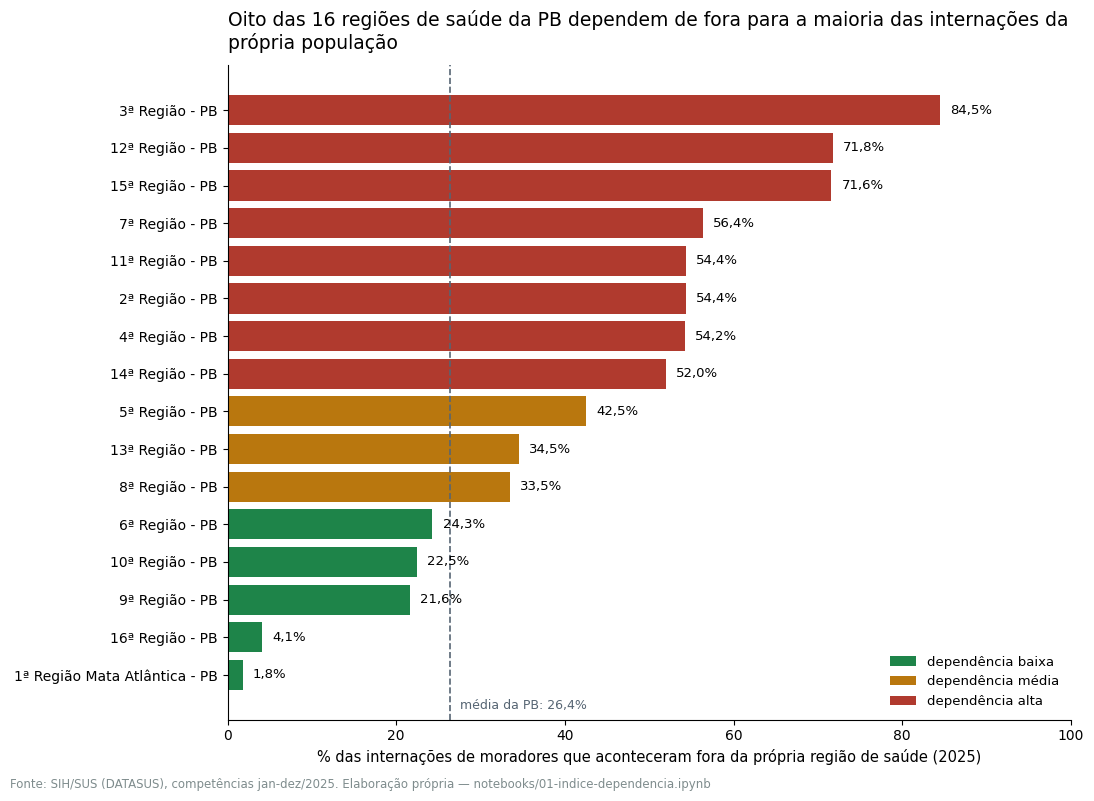

In [10]:
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

grafico = indice_final.sort_values("indice_dependencia_pct").reset_index(drop=True)
cores_faixa = {"baixa": "#1E8449", "média": "#B9770E", "alta": "#B03A2E"}
cores = grafico["faixa_dependencia"].map(cores_faixa)

fig, ax = plt.subplots(figsize=(11, 8))
barras = ax.barh(grafico["regiao"], grafico["indice_dependencia_pct"], color=cores)
for barra, (_, linha) in zip(barras, grafico.iterrows()):
    ax.text(barra.get_width() + 1.2, barra.get_y() + barra.get_height() / 2,
            br_pct(linha["indice_dependencia_pct"]), va="center", fontsize=9.5)

ax.axvline(media_pb, color="#566573", linestyle="--", linewidth=1.2)
ax.text(media_pb + 1.2, -0.9, f"média da PB: {br_pct(media_pb)}", fontsize=9, color="#566573")

ax.set_xlim(0, 100)
ax.set_xlabel("% das internações de moradores que aconteceram fora da própria região de saúde (2025)", fontsize=10.5)
ax.set_title("Oito das 16 regiões de saúde da PB dependem de fora para a maioria das internações da própria população",
             fontsize=13.5, loc="left", pad=14, wrap=True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)

from matplotlib.patches import Patch
legenda = [Patch(facecolor=c, label=f"dependência {f}") for f, c in cores_faixa.items()]
ax.legend(handles=legenda, loc="lower right", fontsize=9.5, frameon=False)

fig.text(0.01, 0.01,
         "Fonte: SIH/SUS (DATASUS), competências jan-dez/2025. Elaboração própria — "
         "notebooks/01-indice-dependencia.ipynb", fontsize=8.5, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.02, 1, 1])
saida_fig = Path("outputs/figures/indice_ranking_dependencia.png")
fig.savefig(saida_fig, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Salvo: {saida_fig} ({saida_fig.stat().st_size / 1024:.0f} KB, 200 dpi)")
plt.show()

## 11. Veredito

### Validação cruzada: **confirmada, sem divergência**

O índice foi calculado por três caminhos independentes — a matriz já agregada por
região, a matriz municipal remapeada do zero via `regioes_saude_pb.csv` e a base bruta
AIH por AIH, sem nenhuma agregação intermediária — e comparado com um quarto cálculo já
existente de etapa anterior. Os quatro batem exatamente nas 16 regiões (delta < 0,05
ponto percentual, dentro do arredondamento). Não foi encontrado bug. O número está
pronto para o painel.

### O ranking, em uma frase

A rede hospitalar da Paraíba tem **dois polos que resolvem quase tudo sozinhos**
(João Pessoa 1,8% e Campina Grande 4,1% de dependência) e um conjunto grande de regiões
vizinhas a eles que **exportam a maioria das próprias internações** — a mais extrema é a
3ª Região (Esperança/Lagoa Seca/Alagoa Grande...), com 84,5% de dependência de fora,
majoritariamente de Campina Grande. Oito das 16 regiões estão na faixa "dependência
alta" (>50%): a maioria das internações da própria população não acontece dentro de
casa — e essa proporção (8/16 = 50%) confirma com folga a hipótese PA-2 (limiar de 1/3),
como detalhado na seção 8.

### Limitações

As limitações completas (a-f) estão documentadas em
`docs/definicao-indice-dependencia.md`, seção 6, e não são repetidas por inteiro aqui
para não duplicar fonte de verdade. As duas mais relevantes para quem for usar este
número:

- **O índice é um piso, não o valor real.** Paraibanos internados em hospitais de outro
  estado (Pernambuco, Rio Grande do Norte, Ceará) não aparecem nesta base — a
  dependência real de cada região é igual ou maior que a mostrada aqui, nunca menor.
- **Região pequena tem número mais instável.** A menor região (13ª, 4.277 internações de
  residentes) tem menos "massa" que a maior (1ª Mata Atlântica, 81.574) — por isso a
  tabela final sempre mostra o volume ao lado do índice, nunca o índice sozinho.

### Teste de leitura com o Pedro — pendente de ação humana

Este notebook **não** conduziu nem simulou essa conversa. O documento de definição
(`docs/definicao-indice-dependencia.md`, seção final) já lista o roteiro a ser aplicado
pelo Augusto com o Pedro:

1. Com suas palavras, o que o número "84,5% na 3ª Região" quer dizer?
2. Se uma região tivesse índice 0%, o que estaria acontecendo lá?
3. Índice alto significa que o hospital daquela região é ruim? (resposta esperada: não)
4. Por que o corte de "dependência alta" é 50% e não outro número qualquer?
5. Apontando a tabela do exemplo: de onde saiu o 9.143 e de onde saiu o 10.815?
6. Teve alguma palavra ou frase que precisou reler para entender? Qual?
7. Se fosse explicar isso para a mãe dele em 20 segundos, o que diria?

O resultado deve ser registrado na própria seção final de
`docs/definicao-indice-dependencia.md`, não neste notebook.